# 1. Загрузка, обработка

In [29]:
import pandas as pd
import os
import numpy as np


In [30]:
from pathlib import Path

raw_data_candidates = [
    Path('data/raw'),
    Path('../data/raw'),
]
raw_data_dir = next((path for path in raw_data_candidates if path.exists()), None)
if raw_data_dir is None:
    raise FileNotFoundError('Не найдена папка data/raw. Запустите notebook из корня проекта или из папки notebooks.')

files = [raw_data_dir / f'EURUSD_15min_{year}_Q{quartal}.csv'
         for year in range(2015, 2027)
         for quartal in range(1, 5)]
files = [f for f in files if f.exists()]

if not files:
    raise FileNotFoundError(f'В {raw_data_dir} не найдено CSV-файлов EURUSD_15min_YYYY_QN.csv')

# Чтение и объединение. data/raw не изменяем, только читаем.
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# Обработка времени
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=False).dt.tz_localize(None)
df = df.drop_duplicates(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

print('Файлов загружено:', len(files))
print('Период:', df['timestamp'].min(), '->', df['timestamp'].max())
print('Строк:', len(df))

Файлов загружено: 45
Период: 2014-12-31 18:00:00 -> 2026-03-26 16:30:00
Строк: 277105


In [31]:
df.head()

,timestamp,open,high,low,close,volume
0,2014-12-31 18:00:00,1.20997,1.21070,1.20997,1.21048,1118.83
1,2014-12-31 18:15:00,1.21047,1.21079,1.21042,1.21067,523.99
2,2014-12-31 18:30:00,1.21068,1.21069,1.21000,1.21019,690.66
3,2014-12-31 18:45:00,1.21018,1.21018,1.20984,1.21010,725.78
4,2014-12-31 19:00:00,1.21010,1.21037,1.20982,1.20997,750.45


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277105 entries, 0 to 277104
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  277105 non-null  datetime64[us]
 1   open       277105 non-null  float64       
 2   high       277105 non-null  float64       
 3   low        277105 non-null  float64       
 4   close      277105 non-null  float64       
 5   volume     277105 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 12.7 MB


In [33]:
#поставим timestamp индексом
df.set_index('timestamp', inplace=True)
df.head()

,open,high,low,close,volume
timestamp,,,,,
2014-12-31 18:00:00,1.20997,1.21070,1.20997,1.21048,1118.83
2014-12-31 18:15:00,1.21047,1.21079,1.21042,1.21067,523.99
2014-12-31 18:30:00,1.21068,1.21069,1.21000,1.21019,690.66
2014-12-31 18:45:00,1.21018,1.21018,1.20984,1.21010,725.78
2014-12-31 19:00:00,1.21010,1.21037,1.20982,1.20997,750.45


## 1.1 Создание признаков

Создаём признаки, которые нужны и для Event Detector, и для Direction Model. Этот блок должен идти после установки `timestamp` индексом и до CUSUM.

In [34]:
# Создание признаков для Event Detector и Direction Model
# Важно: все признаки здесь считаются только из текущих/прошлых свечей.

price = df['close'].replace(0, np.nan)
open_price = df['open'].replace(0, np.nan)

# 1. Доходности и импульсы. Они стабильнее абсолютных цен для out-of-sample лет.
df['returns'] = df['close'].pct_change()
df['log_returns'] = np.log(df['close']).diff()

for window in [4, 8, 16, 32, 96]:
    df[f'momentum_{window}'] = df['close'].pct_change(window)

# 2. Свечные признаки.
df['range_pct'] = (df['high'] - df['low']) / price
df['body_pct'] = (df['close'] - df['open']) / open_price
df['body_abs_pct'] = df['body_pct'].abs()
df['upper_wick_pct'] = (df['high'] - df[['open', 'close']].max(axis=1)) / price
df['lower_wick_pct'] = (df[['open', 'close']].min(axis=1) - df['low']) / price
df['close_position'] = (df['close'] - df['low']) / (df['high'] - df['low']).replace(0, np.nan)

# 3. Скользящие средние в виде расстояния цены от средней.
df['ma_10'] = df['close'].rolling(10).mean()
df['ma_20'] = df['close'].rolling(20).mean()
df['ma_50'] = df['close'].rolling(50).mean()
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()

df['ma_10_diff'] = (df['close'] - df['ma_10']) / price
df['ma_20_diff'] = (df['close'] - df['ma_20']) / price
df['ma_50_diff'] = (df['close'] - df['ma_50']) / price
df['ema_12_diff'] = (df['close'] - df['ema_12']) / price
df['ema_26_diff'] = (df['close'] - df['ema_26']) / price

# 4. Волатильность и нормированные объемы.
df['volatility_20'] = df['returns'].rolling(20).std()
df['volatility_96'] = df['returns'].rolling(96).std()
df['range_mean_20'] = df['range_pct'].rolling(20).mean()
df['volume_change'] = df['volume'].pct_change().replace([np.inf, -np.inf], np.nan)
df['volume_zscore_96'] = (
    (df['volume'] - df['volume'].rolling(96).mean()) /
    df['volume'].rolling(96).std().replace(0, np.nan)
)

# 5. Время суток и день недели в циклическом виде.
df['hour_float'] = df.index.hour + df.index.minute / 60
df['time_sin'] = np.sin(2 * np.pi * df['hour_float'] / 24)
df['time_cos'] = np.cos(2 * np.pi * df['hour_float'] / 24)

df['day_of_week'] = df.index.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 6. Простые уровни support/resistance через rolling max/min.
df['rolling_max_50'] = df['high'].rolling(50).max()
df['rolling_min_50'] = df['low'].rolling(50).min()

df['dist_to_res'] = (df['rolling_max_50'] - df['close']) / price
df['dist_to_sup'] = (df['close'] - df['rolling_min_50']) / price

df['break_res'] = (df['close'] > df['rolling_max_50'].shift(1)).astype(int)
df['break_sup'] = (df['close'] < df['rolling_min_50'].shift(1)).astype(int)

# 7. RSI 14, сразу нормируем в диапазон около [-0.5, 0.5].
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df['rsi_14'] = 100 - (100 / (1 + rs))
df['rsi_14_norm'] = (df['rsi_14'] - 50) / 100

# Удаляем NaN/inf после rolling/diff.
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print('Признаки созданы.')
print('Количество строк после dropna:', len(df))
display(df[[
    'returns', 'momentum_8', 'range_pct', 'body_pct',
    'ma_20_diff', 'volatility_96', 'time_sin', 'time_cos',
    'dow_sin', 'dow_cos', 'dist_to_res', 'dist_to_sup',
    'break_res', 'break_sup', 'rsi_14_norm'
]].tail())

Признаки созданы.
Количество строк после dropna: 276922


,returns,momentum_8,range_pct,body_pct,ma_20_diff,volatility_96,time_sin,time_cos,dow_sin,dow_cos,dist_to_res,dist_to_sup,break_res,break_sup,rsi_14_norm
timestamp,,,,,,,,,,,,,,,
2026-03-26 15:30:00,-0.000953,-0.001429,0.001136,-0.000944,-0.000688,0.000371,-0.793353,-0.608761,0.433884,-0.900969,0.003416,0.000910,0,0,0.008955
2026-03-26 15:45:00,0.000746,-0.000069,0.000927,0.000728,0.000125,0.000379,-0.831470,-0.555570,0.433884,-0.900969,0.002669,0.001655,0,0,0.055405
2026-03-26 16:00:00,0.000078,-0.000035,0.000537,0.000087,0.000240,0.000373,-0.866025,-0.500000,0.433884,-0.900969,0.002590,0.001733,0,0,0.109579
2026-03-26 16:15:00,-0.000650,-0.001152,0.001023,-0.000641,-0.000371,0.000367,-0.896873,-0.442289,0.433884,-0.900969,0.003242,0.001084,0,0,0.000000
2026-03-26 16:30:00,0.000191,-0.000528,0.000520,0.000182,-0.000196,0.000368,-0.923880,-0.382683,0.433884,-0.900969,0.003051,0.001274,0,0,-0.022003


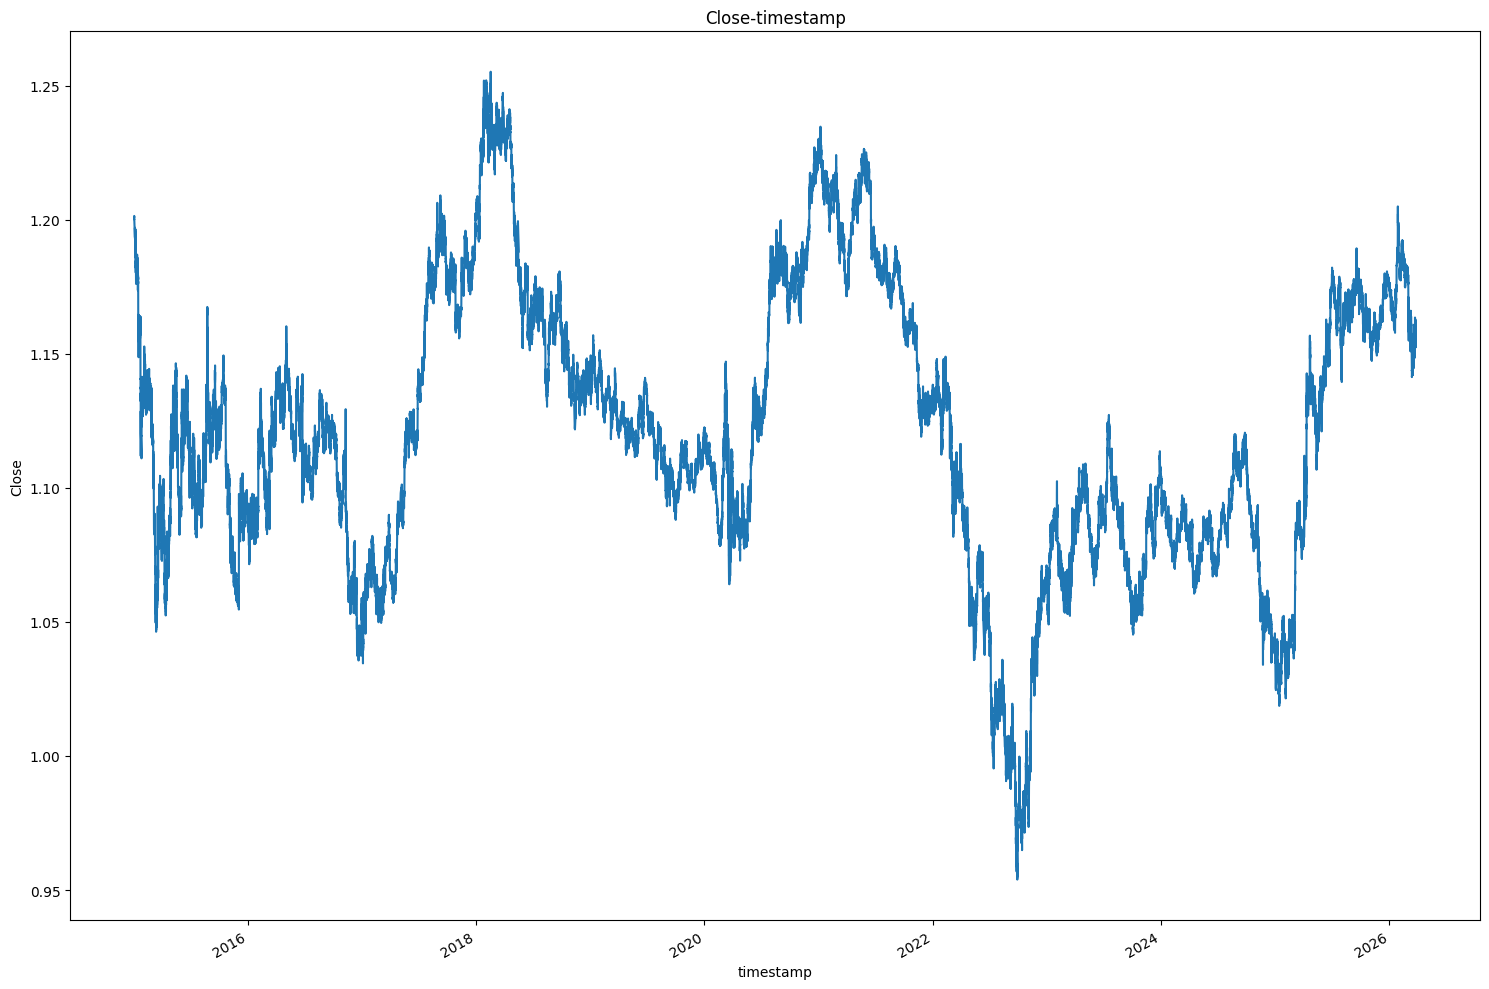

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
plt.subplots_adjust(top=1.25, bottom =1.2)

plt.subplot()
df['close'].plot()
plt.ylabel('Close')
plt.xlabel('timestamp')
plt.title('Close-timestamp')
plt.tight_layout()

## 1.2 Event Detector

В этом разделе создаём rule-based Event Detector. Его задача — не предсказывать BUY/SELL, а отметить свечи, где вообще есть смысл запускать модель направления.

`event = 0` — обычная свеча, пропускаем.  
`event = 1` — есть событие, дальше можно запускать Direction Model.


In [36]:
# Event Detector: вспомогательные признаки

level_lookback_fast = 50
level_lookback_slow = 96

# Уровни считаем через shift(1), чтобы текущая свеча не создавала сама себе уровень.
df['prev_resistance_50'] = df['high'].rolling(level_lookback_fast).max().shift(1)
df['prev_support_50'] = df['low'].rolling(level_lookback_fast).min().shift(1)
df['prev_resistance_96'] = df['high'].rolling(level_lookback_slow).max().shift(1)
df['prev_support_96'] = df['low'].rolling(level_lookback_slow).min().shift(1)

# Расстояние до предыдущего сопротивления / поддержки.
df['dist_to_prev_res'] = (df['prev_resistance_50'] - df['close']) / df['close']
df['dist_to_prev_sup'] = (df['close'] - df['prev_support_50']) / df['close']
df['dist_to_prev_res_96'] = (df['prev_resistance_96'] - df['close']) / df['close']
df['dist_to_prev_sup_96'] = (df['close'] - df['prev_support_96']) / df['close']

# Используем те же свечные признаки, которые потом увидит GRU.
df['candle_range'] = df['range_pct']
df['candle_body'] = df['body_abs_pct']
df['candle_body_signed'] = df['body_pct']

# Средний размер свечи за прошлые 20 свечей.
df['avg_range_20'] = df['candle_range'].rolling(20).mean().shift(1)
df['avg_body_20'] = df['candle_body'].rolling(20).mean().shift(1)
df['range_ratio_20'] = df['candle_range'] / df['avg_range_20'].replace(0, np.nan)
df['body_ratio_20'] = df['candle_body'] / df['avg_body_20'].replace(0, np.nan)

print('Event-признаки добавлены')
display(df[[
    'close', 'prev_resistance_50', 'prev_support_50',
    'prev_resistance_96', 'prev_support_96',
    'dist_to_prev_res', 'dist_to_prev_sup',
    'range_ratio_20', 'body_ratio_20'
]].tail())

Event-признаки добавлены


,close,prev_resistance_50,prev_support_50,prev_resistance_96,prev_support_96,dist_to_prev_res,dist_to_prev_sup,range_ratio_20,body_ratio_20
timestamp,,,,,,,,,
2026-03-26 15:30:00,1.15328,1.15722,1.15223,1.15836,1.15223,0.003416,0.000910,1.438279,2.168710
2026-03-26 15:45:00,1.15414,1.15722,1.15223,1.15836,1.15223,0.002669,0.001655,1.125630,1.542372
2026-03-26 16:00:00,1.15423,1.15722,1.15223,1.15836,1.15223,0.002590,0.001733,0.636749,0.172846
2026-03-26 16:15:00,1.15348,1.15722,1.15223,1.15836,1.15223,0.003242,0.001084,1.222674,1.339036
2026-03-26 16:30:00,1.15370,1.15722,1.15223,1.15836,1.15223,0.003051,0.001274,0.614867,0.379874


In [37]:
# Event Detector: CUSUM-фильтр

# CUSUM отмечает моменты, когда накопленное движение стало большим относительно недавней волатильности.
def add_cusum_events(dataframe, return_col='returns', volatility_window=96, threshold_mult=2.8):
    df_local = dataframe.copy()

    rolling_vol = df_local[return_col].rolling(volatility_window).std().shift(1)
    vol_floor = rolling_vol.rolling(volatility_window * 5, min_periods=volatility_window).quantile(0.10).shift(1)
    stable_vol = np.maximum(rolling_vol, vol_floor)
    stable_vol = stable_vol.bfill().fillna(stable_vol.median())

    df_local['cusum_threshold'] = stable_vol * threshold_mult

    pos_sum = 0.0
    neg_sum = 0.0
    events = []
    event_direction = []

    for ret, threshold in zip(df_local[return_col].fillna(0).values, df_local['cusum_threshold'].values):
        if not np.isfinite(threshold) or threshold <= 0:
            events.append(0)
            event_direction.append(0)
            continue

        pos_sum = max(0.0, pos_sum + ret)
        neg_sum = min(0.0, neg_sum + ret)

        if pos_sum > threshold:
            events.append(1)
            event_direction.append(1)
            pos_sum = 0.0
            neg_sum = 0.0
        elif neg_sum < -threshold:
            events.append(1)
            event_direction.append(-1)
            pos_sum = 0.0
            neg_sum = 0.0
        else:
            events.append(0)
            event_direction.append(0)

    df_local['event_cusum'] = events
    df_local['event_cusum_direction'] = event_direction
    return df_local


df = add_cusum_events(
    dataframe=df,
    return_col='returns',
    volatility_window=96,
    threshold_mult=2.8
)

print('CUSUM events:', df['event_cusum'].sum())
display(df[['returns', 'cusum_threshold', 'event_cusum', 'event_cusum_direction']].tail())

CUSUM events: 28564


,returns,cusum_threshold,event_cusum,event_cusum_direction
timestamp,,,,
2026-03-26 15:30:00,-0.000953,0.001054,1,-1
2026-03-26 15:45:00,0.000746,0.001050,0,0
2026-03-26 16:00:00,0.000078,0.001062,0,0
2026-03-26 16:15:00,-0.000650,0.001049,0,0
2026-03-26 16:30:00,0.000191,0.001048,0,0


In [38]:
# Event Detector: финальное правило event

near_level_threshold = 0.00045
strong_range_multiplier = 1.8
strong_body_multiplier = 1.6

# Цена рядом с прошлым сопротивлением или поддержкой на fast/slow lookback.
df['near_resistance'] = (
    (df['dist_to_prev_res'].abs() < near_level_threshold) |
    (df['dist_to_prev_res_96'].abs() < near_level_threshold)
)
df['near_support'] = (
    (df['dist_to_prev_sup'].abs() < near_level_threshold) |
    (df['dist_to_prev_sup_96'].abs() < near_level_threshold)
)
df['near_level'] = df['near_resistance'] | df['near_support']

# Сильная свеча: range или тело больше обычного.
df['strong_range'] = df['range_ratio_20'] > strong_range_multiplier
df['strong_body'] = df['body_ratio_20'] > strong_body_multiplier
df['strong_candle'] = df['strong_range'] | df['strong_body']

# Пробой прошлых уровней.
df['breakout_up'] = (
    (df['close'] > df['prev_resistance_50']) |
    (df['close'] > df['prev_resistance_96'])
)
df['breakout_down'] = (
    (df['close'] < df['prev_support_50']) |
    (df['close'] < df['prev_support_96'])
)
df['breakout'] = df['breakout_up'] | df['breakout_down']

# Финальный event: CUSUM + рыночный контекст.
df['event'] = (
    (df['event_cusum'] == 1) &
    (df['near_level'] | df['strong_candle'] | df['breakout'])
).astype(int)

df = df.replace([np.inf, -np.inf], np.nan).dropna()

print('Всего строк:', len(df))
print('Всего event=1:', df['event'].sum())
print('Доля event=1:', round(df['event'].mean() * 100, 4), '%')

print('Последние события:')
display(df[df['event'] == 1][[
    'open', 'high', 'low', 'close',
    'event_cusum_direction',
    'near_level', 'strong_candle', 'breakout',
    'dist_to_prev_res', 'dist_to_prev_sup',
    'dist_to_prev_res_96', 'dist_to_prev_sup_96'
]].tail(10))

Всего строк: 276826
Всего event=1: 21674
Доля event=1: 7.8295 %
Последние события:


,open,high,low,close,event_cusum_direction,near_level,strong_candle,breakout,dist_to_prev_res,dist_to_prev_sup,dist_to_prev_res_96,dist_to_prev_sup_96
timestamp,,,,,,,,,,,,
2026-03-25 02:00:00,1.16120,1.16129,1.16043,1.16060,-1,False,True,False,0.002111,0.004231,0.002111,0.004231
2026-03-25 08:00:00,1.15977,1.16082,1.15906,1.16063,1,False,True,False,0.002085,0.002033,0.002085,0.004256
2026-03-25 09:15:00,1.16041,1.16045,1.15959,1.15970,-1,False,True,False,0.002889,0.000888,0.002889,0.003458
2026-03-25 12:30:00,1.15952,1.15980,1.15905,1.15916,-1,True,False,False,0.003356,0.000423,0.003356,0.002994
2026-03-25 13:45:00,1.15802,1.15813,1.15716,1.15728,-1,False,True,True,0.004450,-0.000493,0.004986,0.001374
2026-03-25 15:30:00,1.15748,1.15779,1.15651,1.15677,-1,True,True,False,0.004219,0.000173,0.005429,0.000934
2026-03-26 06:00:00,1.15576,1.15604,1.15542,1.15544,-1,True,False,False,0.002527,0.000043,0.005375,0.000043
2026-03-26 11:00:00,1.15572,1.15586,1.15508,1.15510,-1,True,True,False,0.001835,0.000312,0.005411,0.000312
2026-03-26 11:30:00,1.15437,1.15445,1.15320,1.15333,-1,False,True,True,0.003373,-0.000832,0.006954,-0.000832


In [39]:
# Event Detector: сколько сигналов в день

signals_per_day = df['event'].resample('1D').sum()

print('Статистика сигналов в день:')
print(signals_per_day.describe())

print('Среднее сигналов в день:', round(signals_per_day.mean(), 3))
print('Медиана сигналов в день:', round(signals_per_day.median(), 3))
print('Максимум сигналов в день:', int(signals_per_day.max()))

print('Топ-10 дней по количеству событий:')
display(signals_per_day.sort_values(ascending=False).head(10))


Статистика сигналов в день:
count    4099.000000
mean        5.287631
std         3.829896
min         0.000000
25%         1.000000
50%         6.000000
75%         8.000000
max        17.000000
Name: event, dtype: float64
Среднее сигналов в день: 5.288
Медиана сигналов в день: 6.0
Максимум сигналов в день: 17
Топ-10 дней по количеству событий:


timestamp
2022-02-24    17
2020-09-01    16
2019-08-05    16
2016-06-23    16
2023-08-29    15
2019-12-27    15
2020-03-12    15
2021-09-07    15
2025-07-07    15
2021-11-26    15
Name: event, dtype: int64

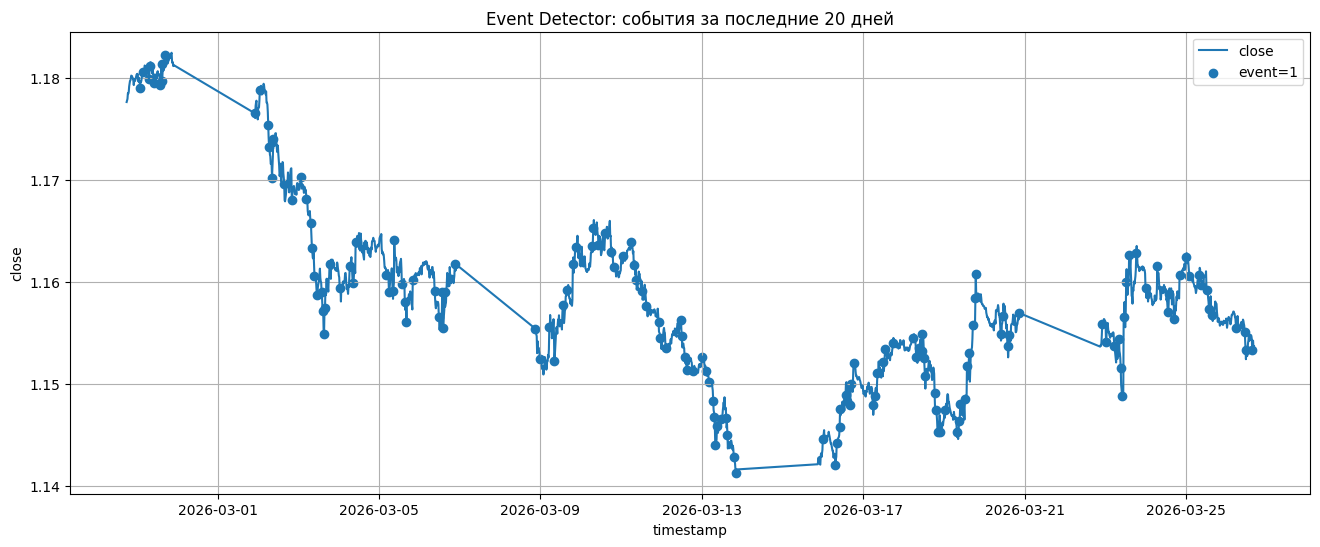

In [40]:
# Event Detector: быстрый график последних событий

import matplotlib.pyplot as plt

plot_days = 20
plot_df = df.tail(96 * plot_days).copy()
events_df = plot_df[plot_df['event'] == 1]

plt.figure(figsize=(16, 6))
plt.plot(plot_df.index, plot_df['close'], label='close')
plt.scatter(events_df.index, events_df['close'], marker='o', label='event=1')
plt.title(f'Event Detector: события за последние {plot_days} дней')
plt.xlabel('timestamp')
plt.ylabel('close')
plt.legend()
plt.grid(True)
plt.show()


## 1.3 Интерпретация Event Detector

Ориентир для 15-минутного EURUSD: 2–5 событий в день — хороший рабочий диапазон. Если событий слишком много, фильтр слабый; если почти нет событий, фильтр слишком строгий.


# 2. Обучение Direction Model


## 2.1 Импорты и зависимости


In [41]:
import os
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

## 2.2 Подготовка train / val / test


In [42]:
# Разделяем данные по времени.
# Важно: перемешивать сам DataFrame нельзя, иначе появится утечка будущего.
train_df = df[df.index < '2021-01-01'].copy()
val_df = df[(df.index >= '2021-01-01') & (df.index < '2024-01-01')].copy()
test_df = df[df.index >= '2024-01-01'].copy()

# Признаки для модели направления.
# event не добавляем как признак: это остается первым этапом робота, а GRU работает только после event == 1.
feature_columns = [
    'returns', 'log_returns',
    'momentum_4', 'momentum_8', 'momentum_16', 'momentum_32', 'momentum_96',
    'volatility_20', 'volatility_96',
    'range_pct', 'body_pct', 'body_abs_pct', 'upper_wick_pct', 'lower_wick_pct', 'close_position',
    'ma_10_diff', 'ma_20_diff', 'ma_50_diff', 'ema_12_diff', 'ema_26_diff',
    'rsi_14_norm',
    'volume_change', 'volume_zscore_96',
    'time_sin', 'time_cos', 'dow_sin', 'dow_cos',
    'dist_to_res', 'dist_to_sup', 'break_res', 'break_sup',
    'dist_to_prev_res', 'dist_to_prev_sup', 'dist_to_prev_res_96', 'dist_to_prev_sup_96',
    'range_ratio_20', 'body_ratio_20',
    'near_resistance', 'near_support', 'strong_range', 'strong_body', 'breakout_up', 'breakout_down',
    'event_cusum_direction'
]

target_column = 'close'

missing_columns = [col for col in feature_columns + ['event', target_column] if col not in df.columns]
if missing_columns:
    raise ValueError(f'Не найдены колонки: {missing_columns}')

# RobustScaler устойчивее к выбросам на сильных свечах, чем MinMaxScaler.
def build_feature_frame(part_df):
    return (
        part_df[feature_columns]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .astype(np.float32)
    )

scaler = RobustScaler(quantile_range=(5.0, 95.0))

scaled_train = scaler.fit_transform(build_feature_frame(train_df))
scaled_val = scaler.transform(build_feature_frame(val_df))
scaled_test = scaler.transform(build_feature_frame(test_df))

train_features = torch.FloatTensor(scaled_train)
val_features = torch.FloatTensor(scaled_val)
test_features = torch.FloatTensor(scaled_test)

print('Количество признаков:', len(feature_columns))
print('train_features:', train_features.shape)
print('val_features:', val_features.shape)
print('test_features:', test_features.shape)

Количество признаков: 44
train_features: torch.Size([147853, 44])
val_features: torch.Size([73880, 44])
test_features: torch.Size([55093, 44])


## 2.3 Dataset только по event == 1


In [43]:
# GRU получает последние 24 часа 15m-свечей и обязательно включает текущую event-свечу.
sequence_length = 96
batch_size = 384

# Горизонт прогноза: 8 свечей по 15 минут = 2 часа вперед.
prediction_horizon = 8

# Минимальное движение для обучающей метки: около 3.5 пункта для EURUSD.
direction_threshold = 0.00035

# Direction Model обучается только на событиях event == 1 и решает бинарную задачу:
# 0 = SELL, 1 = BUY.
# HOLD остается фильтром уверенности после предсказания.

In [44]:
class EventDirectionDataset(Dataset):
    def __init__(
        self,
        feature_tensor,
        close_series,
        event_series,
        sequence_length,
        prediction_horizon=8,
        threshold=0.00035
    ):
        self.feature_tensor = feature_tensor
        self.close_values = np.asarray(close_series, dtype=np.float32)
        self.event_values = np.asarray(event_series, dtype=np.int64)
        self.sequence_length = sequence_length
        self.prediction_horizon = prediction_horizon
        self.threshold = threshold

        self.samples = []

        # Стартуем с sequence_length - 1, потому что окно включает event-свечу: [i-L+1, ..., i].
        for i in range(sequence_length - 1, len(feature_tensor) - prediction_horizon):
            if self.event_values[i] != 1:
                continue

            label = self._first_touch_label(i)
            if label is None:
                continue

            self.samples.append((i, label))

        if len(self.samples) == 0:
            raise ValueError('Нет подходящих событий. Ослабьте direction_threshold или event detector.')

    def _first_touch_label(self, event_idx):
        current_price = self.close_values[event_idx]
        future_prices = self.close_values[event_idx + 1 : event_idx + self.prediction_horizon + 1]
        future_returns = (future_prices - current_price) / current_price

        up_hits = np.flatnonzero(future_returns >= self.threshold)
        down_hits = np.flatnonzero(future_returns <= -self.threshold)

        # Пропускаем шумовые события, где за горизонт не было значимого движения.
        if len(up_hits) == 0 and len(down_hits) == 0:
            return None

        if len(up_hits) == 0:
            return 0
        if len(down_hits) == 0:
            return 1

        # Если оба барьера достигнуты, берем тот, который случился первым.
        return 1 if up_hits[0] < down_hits[0] else 0

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        event_idx, label = self.samples[idx]
        x = self.feature_tensor[event_idx - self.sequence_length + 1 : event_idx + 1]
        y = torch.tensor(label, dtype=torch.long)
        return x, y

In [45]:
train_dataset = EventDirectionDataset(
    feature_tensor=train_features,
    close_series=train_df[target_column].values,
    event_series=train_df['event'].values,
    sequence_length=sequence_length,
    prediction_horizon=prediction_horizon,
    threshold=direction_threshold
)

val_dataset = EventDirectionDataset(
    feature_tensor=val_features,
    close_series=val_df[target_column].values,
    event_series=val_df['event'].values,
    sequence_length=sequence_length,
    prediction_horizon=prediction_horizon,
    threshold=direction_threshold
)

test_dataset = EventDirectionDataset(
    feature_tensor=test_features,
    close_series=test_df[target_column].values,
    event_series=test_df['event'].values,
    sequence_length=sequence_length,
    prediction_horizon=prediction_horizon,
    threshold=direction_threshold
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

print('train events:', len(train_dataset))
print('val events:', len(val_dataset))
print('test events:', len(test_dataset))

train events: 11066
val events: 5639
test events: 4050


In [46]:
# Проверяем баланс классов в train.
ys = np.array([y.item() for _, y in train_dataset])
class_counts = np.bincount(ys, minlength=2)
class_weights_np = len(ys) / (2 * np.maximum(class_counts, 1))

print('Уникальные значения y:', np.unique(ys))
print('SELL:', round(np.mean(ys == 0), 4), '| count:', int(class_counts[0]))
print('BUY:', round(np.mean(ys == 1), 4), '| count:', int(class_counts[1]))
print('class_weights:', np.round(class_weights_np, 4))

assert set(np.unique(ys)).issubset({0, 1}), 'В y должны быть только классы 0=SELL и 1=BUY'

Уникальные значения y: [0 1]
SELL: 0.5051 | count: 5589
BUY: 0.4949 | count: 5477
class_weights: [0.99   1.0102]


In [47]:
# Проверка размеров одного batch.
x_batch, y_batch = next(iter(train_loader))

print('Размер X batch:', x_batch.shape)
print('Размер y batch:', y_batch.shape)

assert x_batch.ndim == 3, 'X должен иметь размерность [batch_size, sequence_length, input_size]'
assert y_batch.ndim == 1, 'y должен иметь размерность [batch_size]'
assert x_batch.shape[1] == sequence_length, 'Вторая размерность X должна быть равна sequence_length'
assert x_batch.shape[2] == len(feature_columns), 'Третья размерность X должна совпадать с числом признаков'
assert set(y_batch.unique().cpu().numpy()).issubset({0, 1}), 'В batch y должны быть только 0=SELL и 1=BUY'

print('Проверка размеров пройдена успешно.')


Размер X batch: torch.Size([384, 96, 44])
Размер y batch: torch.Size([384])
Проверка размеров пройдена успешно.


## 2.4 Модель GRU


In [48]:
input_size = len(feature_columns)
hidden_size = 96
num_layers = 2
dropout = 0.25
bidirectional = True

num_epochs = 80
learning_rate = 7e-4
weight_decay = 1e-4
patience = 12
grad_clip = 1.0

# Для early stopping сохраняем модель по целевой directional-метрике, а не только по loss.
early_stopping_min_delta = 1e-4

# Для HOLD-фильтра дальше подберем порог на validation.
min_val_trade_coverage = 0.05

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Используемое устройство:', device)

Используемое устройство: cuda


In [49]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=96, num_layers=2, dropout=0.25, num_classes=2, bidirectional=True):
        super().__init__()

        gru_dropout = dropout if num_layers > 1 else 0.0
        self.bidirectional = bidirectional
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout,
            bidirectional=bidirectional
        )

        gru_output_size = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.LayerNorm(gru_output_size),
            nn.Dropout(dropout),
            nn.Linear(gru_output_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # x: [batch_size, sequence_length, input_size]
        out, _ = self.gru(x)
        out = out[:, -1, :]
        logits = self.head(out)
        return logits


model = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=2,
    bidirectional=bidirectional
).to(device)

print(model)

with torch.no_grad():
    test_logits = model(x_batch.to(device))

print('Размер logits:', test_logits.shape)
assert test_logits.shape[1] == 2, 'Модель должна возвращать 2 выхода: SELL / BUY'

GRUModel(
  (gru): GRU(44, 96, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (head): Sequential(
    (0): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=192, out_features=96, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.25, inplace=False)
    (5): Linear(in_features=96, out_features=2, bias=True)
  )
)
Размер logits: torch.Size([384, 2])


## 2.5 Обучение


In [50]:
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.02)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

os.makedirs('models', exist_ok=True)
model_save_path = os.path.join('models', 'gru_event_direction_best.pth')
scaler_save_path = os.path.join('models', 'gru_event_direction_scaler.pkl')

best_val_score = -float('inf')
best_val_loss = float('inf')
early_stopping_counter = 0

train_losses = []
val_losses = []
val_scores = []


def collect_predictions(model, loader):
    model.eval()
    all_targets = []
    all_preds = []
    all_confidences = []
    running_loss = 0.0
    n_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch_device = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch_device)
            probabilities = torch.softmax(logits, dim=1)
            confidence, preds = torch.max(probabilities, dim=1)

            batch_size_current = x_batch.size(0)
            running_loss += loss.item() * batch_size_current
            n_samples += batch_size_current

            all_preds.extend(preds.cpu().numpy())
            all_confidences.extend(confidence.cpu().numpy())
            all_targets.extend(y_batch.numpy())

    all_targets = np.array(all_targets)
    all_preds = np.array(all_preds)
    all_confidences = np.array(all_confidences)
    avg_loss = running_loss / max(n_samples, 1)

    metrics = {
        'mse': mean_squared_error(all_targets, all_preds),
        'accuracy': accuracy_score(all_targets, all_preds),
        'f1_macro': f1_score(all_targets, all_preds, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(all_targets, all_preds)
    }
    return avg_loss, metrics, all_targets, all_preds, all_confidences

In [51]:
for epoch in range(num_epochs):
    # =========================
    # обучение
    # =========================
    model.train()
    running_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        running_train_loss += loss.item() * x_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # =========================
    # валидация
    # =========================
    epoch_val_loss, val_metrics_epoch, _, _, _ = collect_predictions(model, val_loader)
    scheduler.step(epoch_val_loss)

    epoch_val_score = (val_metrics_epoch['f1_macro'] + val_metrics_epoch['balanced_accuracy']) / 2
    val_losses.append(epoch_val_loss)
    val_scores.append(epoch_val_score)

    print(
        f'Epoch [{epoch + 1}/{num_epochs}] | '
        f'train_loss: {epoch_train_loss:.6f} | '
        f'val_loss: {epoch_val_loss:.6f} | '
        f'val_acc: {val_metrics_epoch["accuracy"]:.6f} | '
        f'val_f1: {val_metrics_epoch["f1_macro"]:.6f} | '
        f'val_bal_acc: {val_metrics_epoch["balanced_accuracy"]:.6f}'
    )

    improved = (
        epoch_val_score > best_val_score + early_stopping_min_delta or
        (abs(epoch_val_score - best_val_score) <= early_stopping_min_delta and epoch_val_loss < best_val_loss)
    )

    if improved:
        best_val_score = epoch_val_score
        best_val_loss = epoch_val_loss
        early_stopping_counter = 0

        torch.save(model.state_dict(), model_save_path)
        with open(scaler_save_path, 'wb') as f:
            pickle.dump(scaler, f)

        print(f'  -> Найдена лучшая модель. val_score={best_val_score:.6f}. Веса сохранены в: {model_save_path}')
    else:
        early_stopping_counter += 1
        print(f'  -> Улучшения нет. Счетчик early stopping: {early_stopping_counter}/{patience}')

        if early_stopping_counter >= patience:
            print('Early stopping сработал. Обучение остановлено.')
            break

print(f'\nЛучший val_score: {best_val_score:.6f}')
print(f'Лучший val_loss: {best_val_loss:.6f}')
print(f'Путь к сохраненным весам: {model_save_path}')
print(f'Путь к сохраненному scaler: {scaler_save_path}')

Epoch [1/80] | train_loss: 0.697998 | val_loss: 0.690423 | val_acc: 0.537684 | val_f1: 0.535707 | val_bal_acc: 0.537003
  -> Найдена лучшая модель. val_score=0.536355. Веса сохранены в: models/gru_event_direction_best.pth
Epoch [2/80] | train_loss: 0.691319 | val_loss: 0.690343 | val_acc: 0.535911 | val_f1: 0.535910 | val_bal_acc: 0.535998
  -> Улучшения нет. Счетчик early stopping: 1/12
Epoch [3/80] | train_loss: 0.690708 | val_loss: 0.689992 | val_acc: 0.537329 | val_f1: 0.537036 | val_bal_acc: 0.537110
  -> Найдена лучшая модель. val_score=0.537073. Веса сохранены в: models/gru_event_direction_best.pth
Epoch [4/80] | train_loss: 0.689047 | val_loss: 0.690445 | val_acc: 0.538925 | val_f1: 0.538821 | val_bal_acc: 0.538823
  -> Найдена лучшая модель. val_score=0.538822. Веса сохранены в: models/gru_event_direction_best.pth
Epoch [5/80] | train_loss: 0.688807 | val_loss: 0.690504 | val_acc: 0.538571 | val_f1: 0.538544 | val_bal_acc: 0.538554
  -> Улучшения нет. Счетчик early stopping: 1

## 2.6 Тестирование и метрики


In [52]:
# Загружаем лучшие сохраненные веса.
best_model = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=2,
    bidirectional=bidirectional
).to(device)

best_model.load_state_dict(torch.load(model_save_path, map_location=device))
best_model.eval()

val_loss_final, val_metrics, val_targets, val_preds, val_confidences = collect_predictions(best_model, val_loader)
test_loss_final, metrics, all_targets, all_preds, all_confidences = collect_predictions(best_model, test_loader)

print('Метрики на validation:')
for name, value in val_metrics.items():
    print(f'{name}: {value:.6f}')

print('\nМетрики на test:')
for name, value in metrics.items():
    print(f'{name}: {value:.6f}')

print('\nConfusion matrix на test [[SELL, BUY], [SELL, BUY]]:')
print(confusion_matrix(all_targets, all_preds))

print('\nКлассы:')
print('0 = SELL')
print('1 = BUY')

Метрики на validation:
mse: 0.461075
accuracy: 0.538925
f1_macro: 0.538821
balanced_accuracy: 0.538823

Метрики на test:
mse: 0.473580
accuracy: 0.526420
f1_macro: 0.526301
balanced_accuracy: 0.526695

Confusion matrix на test [[SELL, BUY], [SELL, BUY]]:
[[1098  902]
 [1016 1034]]

Классы:
0 = SELL
1 = BUY


In [53]:
# Распределение классов и HOLD-фильтр уверенности.
print('Реальное распределение классов:')
print('SELL:', round(np.mean(all_targets == 0), 4))
print('BUY:', round(np.mean(all_targets == 1), 4))

print('\nПредсказанное распределение классов:')
print('SELL:', round(np.mean(all_preds == 0), 4))
print('BUY:', round(np.mean(all_preds == 1), 4))

print('\nУверенность модели:')
print('Средняя уверенность:', round(all_confidences.mean(), 4))
print('Медианная уверенность:', round(np.median(all_confidences), 4))
print('Минимальная уверенность:', round(all_confidences.min(), 4))
print('Максимальная уверенность:', round(all_confidences.max(), 4))


def choose_confidence_threshold(targets, preds, confidences, min_coverage=0.05):
    rows = []
    for threshold in np.arange(0.50, 0.86, 0.01):
        mask = confidences >= threshold
        coverage = mask.mean()
        if mask.sum() == 0:
            continue
        acc = accuracy_score(targets[mask], preds[mask])
        f1 = f1_score(targets[mask], preds[mask], average='macro')
        bal_acc = balanced_accuracy_score(targets[mask], preds[mask])
        rows.append({
            'threshold': float(round(threshold, 2)),
            'coverage': float(coverage),
            'accuracy': float(acc),
            'f1_macro': float(f1),
            'balanced_accuracy': float(bal_acc),
            'n_signals': int(mask.sum())
        })

    table = pd.DataFrame(rows)
    eligible = table[table['coverage'] >= min_coverage].copy()
    if eligible.empty:
        eligible = table.copy()

    eligible['score'] = (eligible['f1_macro'] + eligible['balanced_accuracy']) / 2
    best_row = eligible.sort_values(['score', 'accuracy', 'coverage'], ascending=[False, False, False]).iloc[0]
    return float(best_row['threshold']), table


confidence_threshold, threshold_table = choose_confidence_threshold(
    val_targets,
    val_preds,
    val_confidences,
    min_coverage=min_val_trade_coverage
)

trade_mask = all_confidences >= confidence_threshold

print('\nЛучшие confidence thresholds на validation:')
display(threshold_table.sort_values(['f1_macro', 'balanced_accuracy'], ascending=False).head(10))

print('\nФильтр уверенности на test:')
print('Порог уверенности:', confidence_threshold)
print('Доля событий, по которым модель готова торговать:', round(trade_mask.mean(), 4))
print('Количество уверенных сигналов:', int(trade_mask.sum()))

if trade_mask.sum() > 0:
    print('Accuracy только на уверенных сигналах:', round(accuracy_score(all_targets[trade_mask], all_preds[trade_mask]), 6))
    print('F1 macro только на уверенных сигналах:', round(f1_score(all_targets[trade_mask], all_preds[trade_mask], average='macro'), 6))
    print('Balanced accuracy только на уверенных сигналах:', round(balanced_accuracy_score(all_targets[trade_mask], all_preds[trade_mask]), 6))
else:
    print('Нет уверенных сигналов. Уменьшите min_val_trade_coverage или диапазон threshold.')

Реальное распределение классов:
SELL: 0.4938
BUY: 0.5062

Предсказанное распределение классов:
SELL: 0.522
BUY: 0.478

Уверенность модели:
Средняя уверенность: 0.5361
Медианная уверенность: 0.5342
Минимальная уверенность: 0.5
Максимальная уверенность: 0.6542

Лучшие confidence thresholds на validation:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use th

,threshold,coverage,accuracy,f1_macro,balanced_accuracy,n_signals
16,0.66,0.000177,1.000000,1.000000,1.000000,1
17,0.67,0.000177,1.000000,1.000000,1.000000,1
18,0.68,0.000177,1.000000,1.000000,1.000000,1
19,0.69,0.000177,1.000000,1.000000,1.000000,1
20,0.70,0.000177,1.000000,1.000000,1.000000,1
7,0.57,0.065437,0.579946,0.568538,0.570311,369
5,0.55,0.243483,0.554261,0.552025,0.554109,1373
8,0.58,0.032275,0.593407,0.550887,0.560897,182
10,0.60,0.011172,0.666667,0.550764,0.564856,63
6,0.56,0.124845,0.549716,0.549388,0.549416,704



Фильтр уверенности на test:
Порог уверенности: 0.57
Доля событий, по которым модель готова торговать: 0.0612
Количество уверенных сигналов: 248
Accuracy только на уверенных сигналах: 0.568548
F1 macro только на уверенных сигналах: 0.565432
Balanced accuracy только на уверенных сигналах: 0.570062


In [54]:
print('Итоговый файл весов:', model_save_path)
print('Итоговый файл scaler:', scaler_save_path)
print('Итоговый confidence_threshold:', confidence_threshold)
print('Итоговые параметры GRU:', {
    'input_size': input_size,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'dropout': dropout,
    'bidirectional': bidirectional,
    'sequence_length': sequence_length,
    'prediction_horizon': prediction_horizon,
    'direction_threshold': direction_threshold,
})

Итоговый файл весов: models/gru_event_direction_best.pth
Итоговый файл scaler: models/gru_event_direction_scaler.pkl
Итоговый confidence_threshold: 0.57
Итоговые параметры GRU: {'input_size': 44, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.25, 'bidirectional': True, 'sequence_length': 96, 'prediction_horizon': 8, 'direction_threshold': 0.00035}
